In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SVM Iris Classifier — Activity 1
**Dataset:** UCI Iris (`iris/iris.data`) — 150 samples, 4 features, 3 classes  
**Model:** Support Vector Machine with a **linear kernel**

In [2]:
import os

# Path to local iris.data (relative to this notebook)
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("Activity1.ipynb")),
                         "iris", "iris.data")

COLUMNS = ["sepal length (cm)", "sepal width (cm)",
           "petal length (cm)", "petal width (cm)", "species"]

df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS)

print("First 5 rows:")
df.head()

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Clean & Explore

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df["species"].value_counts())
print("\nDescriptive statistics:")
df.describe()

Shape: (150, 5)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Visualise

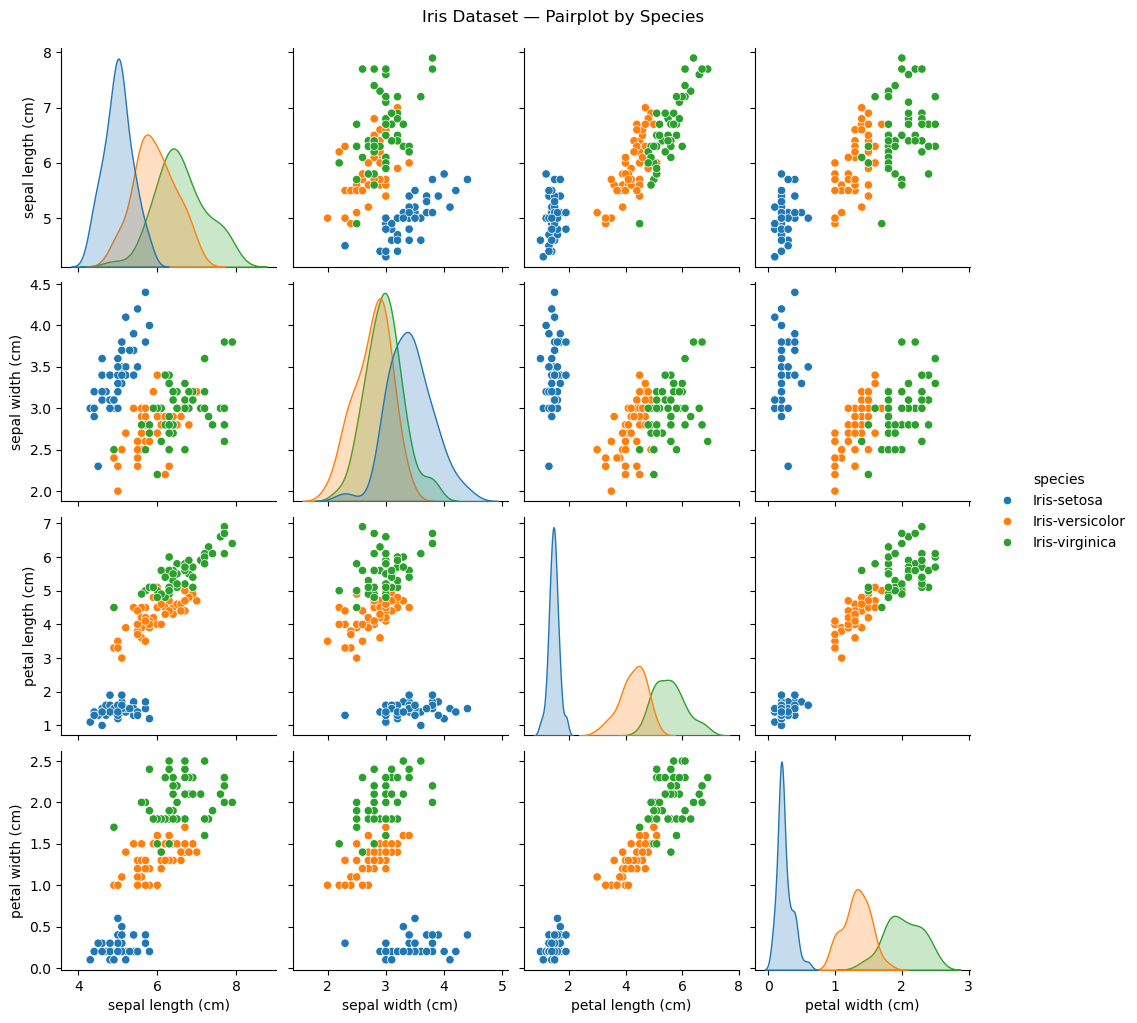

In [4]:
pair = sns.pairplot(df, hue="species")
pair.fig.suptitle("Iris Dataset — Pairplot by Species", y=1.02)

BASE = os.path.dirname(os.path.abspath("Activity1.ipynb"))
pair.fig.savefig(os.path.join(BASE, "iris_pairplot.png"), bbox_inches="tight", dpi=150)
plt.show()

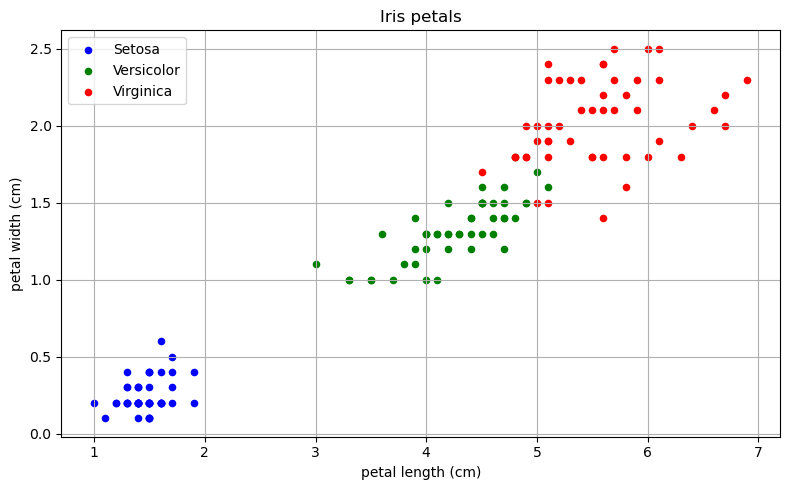

In [5]:
colors = {"Iris-setosa": "blue", "Iris-versicolor": "green", "Iris-virginica": "red"}

fig, ax = plt.subplots(figsize=(8, 5))

for species, group in df.groupby("species"):
    ax.scatter(
        group["petal length (cm)"],
        group["petal width (cm)"],
        label=species.replace("Iris-", "").capitalize(),
        color=colors[species],
        s=20
    )

ax.set_title("Iris petals")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.legend(title=None)
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "iris_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Encode Labels & Split Dataset

In [6]:
le = LabelEncoder()
df["target"] = le.fit_transform(df["species"])   # 0=setosa, 1=versicolor, 2=virginica

X = df[["sepal length (cm)", "sepal width (cm)",
        "petal length (cm)", "petal width (cm)"]].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Classes          : {list(le.classes_)}")

Training samples : 120
Testing  samples : 30
Classes          : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 5. Train SVM (Linear Kernel)

In [7]:
model = SVC(kernel="linear")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained. Predictions on test set complete.")

Model trained. Predictions on test set complete.


## 6. Evaluation Metrics

Accuracy Score : 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


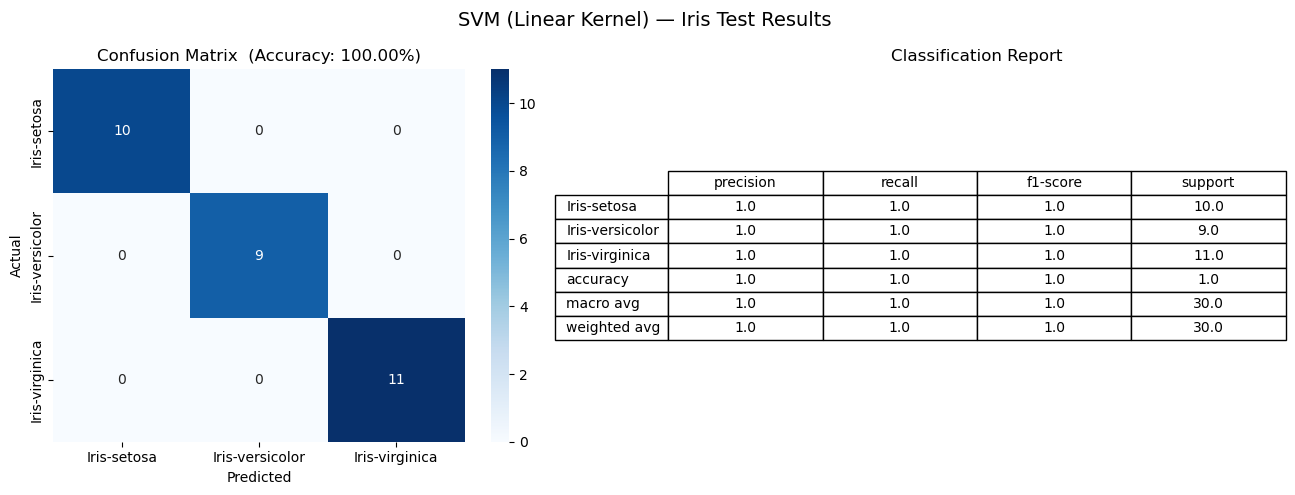

Figures saved: iris_pairplot.png, svm_results.png


In [8]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:")
print(cm)

# ── Results figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SVM (Linear Kernel) — Iris Test Results", fontsize=14)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix  (Accuracy: {accuracy:.2%})")

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)
axes[1].axis("off")
tbl = axes[1].table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
axes[1].set_title("Classification Report")

plt.tight_layout()
plt.savefig(os.path.join(BASE, "svm_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figures saved: iris_pairplot.png, svm_results.png")

## 1. Load Dataset